# Random Forest Classification – Meat Type Prediction

**Target Variable:** `meat_type` (classes 1–5)

**Background:** With a single Decision Tree we achieved 53% accuracy on the
internal test and 27% on the stress test. The middle classes (2, 3, 4)
overlapped in price and couldn't be separated. A Random Forest averages
200 trees — each seeing different rows and features — which should handle
the overlap better.

**Workflow:**
1. Load & explore the dataset
2. Check class distribution and correlations
3. Define features, train/test split (stratified)
4. Train Random Forest Classifier (baseline)
5. Evaluate with classification metrics + confusion matrix
6. Feature importance comparison with Decision Tree
7. Impute and evaluate on the stress-test dataset
8. Compare with Decision Tree results


## Step 1 – Imports

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

print("All imports successful.")


All imports successful.


## Step 2 – Load the Training Dataset

In [15]:
df = pd.read_csv("meat_price_dataset.csv")

print(f"Shape: {df.shape}")
print(f"Missing values:{df.isnull().sum()}")
df.head()


Shape: (1200, 9)
Missing values:meat_type            0
fat_content_pct      0
protein_pct          0
marbling_score       0
animal_age_months    0
storage_days         0
organic              0
cut_quality          0
price_eur_per_kg     0
dtype: int64


,meat_type,fat_content_pct,protein_pct,marbling_score,animal_age_months,storage_days,organic,cut_quality,price_eur_per_kg
0,1,17.8,21.7,7,49,14,1,3,17.27
1,4,27.1,21.9,9,22,4,0,4,29.69
2,4,31.8,16.5,7,20,1,0,2,24.41
3,3,25.8,22.6,6,11,16,0,2,15.08
4,3,33.8,22.4,5,2,17,0,4,20.57


## Step 3 – Exploratory Data Analysis

Class distribution and feature correlations with `meat_type`.


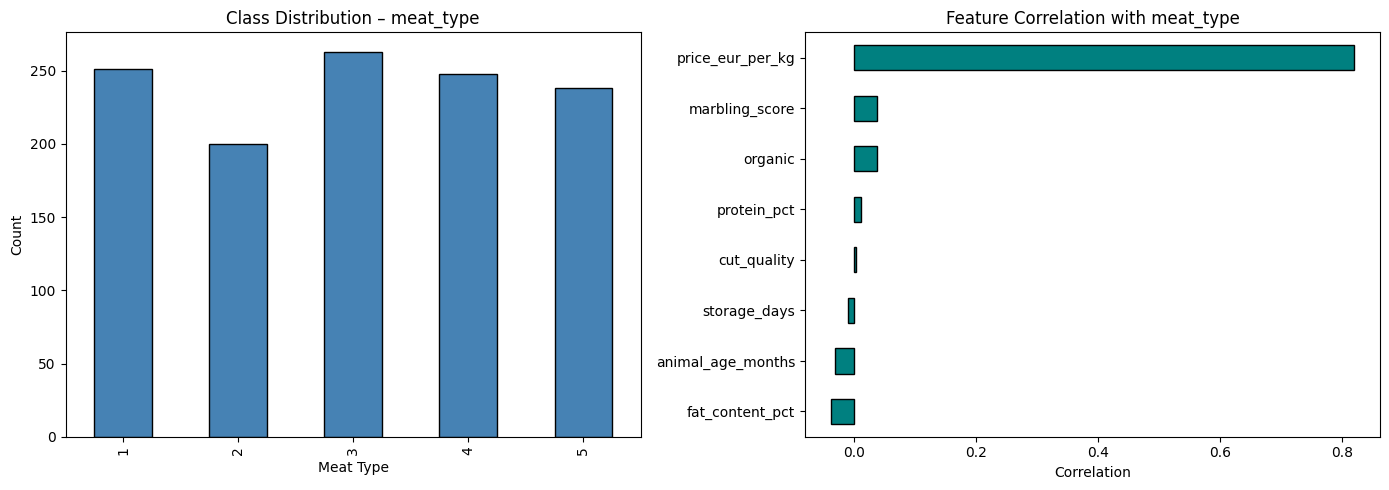

Correlation values:
fat_content_pct     -0.039
animal_age_months   -0.032
storage_days        -0.010
cut_quality          0.003
protein_pct          0.011
organic              0.037
marbling_score       0.038
price_eur_per_kg     0.820
Name: meat_type, dtype: float64


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution
df["meat_type"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="black"
)
axes[0].set_title("Class Distribution – meat_type")
axes[0].set_xlabel("Meat Type")
axes[0].set_ylabel("Count")

# Correlation with meat_type
corr = df.corr()["meat_type"].drop("meat_type").sort_values()
corr.plot(kind="barh", ax=axes[1], color="teal", edgecolor="black")
axes[1].set_title("Feature Correlation with meat_type")
axes[1].set_xlabel("Correlation")

plt.tight_layout()
plt.show()

print("Correlation values:")
print(corr.round(3))


## Step 4 – Define Features and Target


In [17]:
target_col = "meat_type"
feature_cols = [c for c in df.columns if c != target_col]

print("Features:", feature_cols)

X = df[feature_cols]
y = df[target_col]

print(f"X shape: {X.shape}  |  y shape: {y.shape}")
print(f"Classes: {sorted(y.unique())}")


Features: ['fat_content_pct', 'protein_pct', 'marbling_score', 'animal_age_months', 'storage_days', 'organic', 'cut_quality', 'price_eur_per_kg']
X shape: (1200, 8)  |  y shape: (1200,)
Classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


## Step 5 – Train / Test Split (stratified)

`stratify=y` ensures each meat type has the same proportion in
train and test — important for fair evaluation of all classes.


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print(f"Train set: {X_train.shape[0]} rows")
print(f"Test  set: {X_test.shape[0]} rows")
print(f"Class distribution in test set:")
print(y_test.value_counts().sort_index())


Train set: 960 rows
Test  set: 240 rows
Class distribution in test set:
meat_type
1    50
2    40
3    52
4    50
5    48
Name: count, dtype: int64


## Step 6 – Train the Random Forest Classifier

**Key difference to the Regressor:**
- `RandomForestClassifier` instead of `RandomForestRegressor`
- Each leaf votes for a class (not a mean value)
- The forest picks the class with the **most votes** across 200 trees
- Split criterion is `gini` (class impurity) not `mse` (variance)


In [19]:
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=7,
    random_state=42,
    n_jobs=-1,
)

rf_clf.fit(X_train, y_train)

print("Model trained.")
print(f"Number of trees: {rf_clf.n_estimators}")
print(f"Max depth:       {rf_clf.max_depth}")


Model trained.
Number of trees: 200
Max depth:       7


## Step 7 – Evaluate on the Internal Test Set

In [20]:
y_pred = rf_clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred, zero_division=0))


Accuracy: 0.5625
              precision    recall  f1-score   support

           1       0.67      0.84      0.74        50
           2       0.62      0.40      0.48        40
           3       0.45      0.35      0.39        52
           4       0.38      0.48      0.42        50
           5       0.73      0.73      0.73        48

    accuracy                           0.56       240
   macro avg       0.57      0.56      0.55       240
weighted avg       0.56      0.56      0.55       240



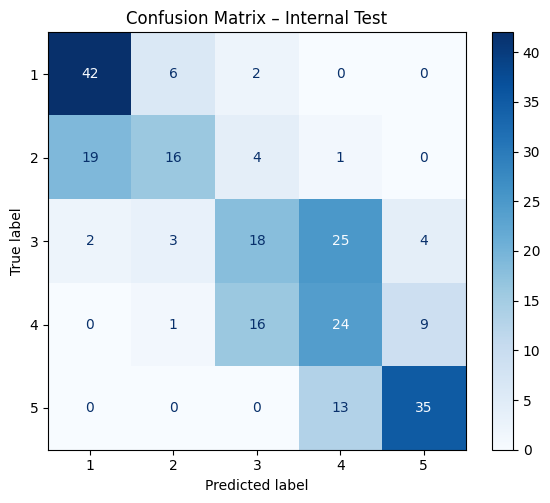

In [21]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Blues")
ax.set_title("Confusion Matrix – Internal Test")
plt.tight_layout()
plt.show()


## Step 8 – Feature Importance

Compare with the Decision Tree to see if the forest distributes
importance more evenly across features.


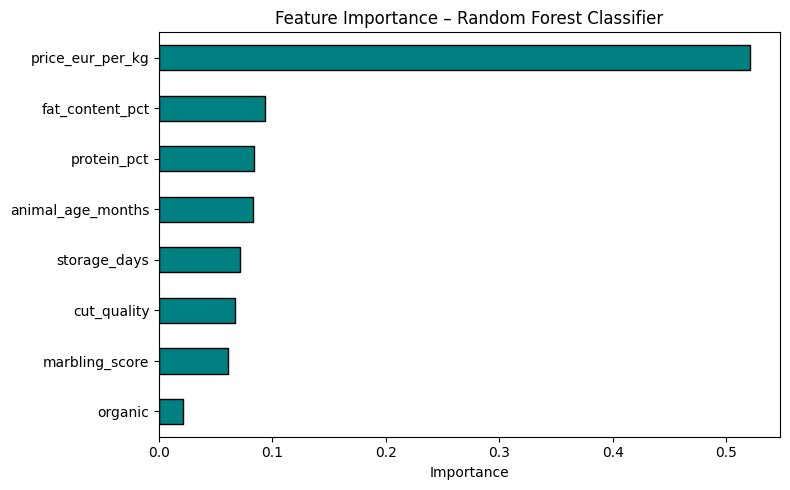

Importance values:
organic              0.0212
marbling_score       0.0606
cut_quality          0.0665
storage_days         0.0711
animal_age_months    0.0827
protein_pct          0.0834
fat_content_pct      0.0931
price_eur_per_kg     0.5215
dtype: float64


In [22]:
importances = pd.Series(rf_clf.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind="barh", ax=ax, color="teal", edgecolor="black")
ax.set_title("Feature Importance – Random Forest Classifier")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print("Importance values:")
print(importances.round(4))


## Step 9 – Load and Impute the Stress-Test Data

Using KNN imputation for better fills, fitted on training data only.


In [23]:
# ============================================================
# DOMAIN-BASED IMPUTATION: Fill NaN per meat_type group
# ============================================================

df_stress = pd.read_csv("meat_price_100_stress_test.csv")

print(f"Shape: {df_stress.shape}")
print(f"\nMissing values BEFORE imputation:")
print(df_stress.isnull().sum())

# --- Step A: Build median lookup per meat_type from TRAINING data ---
# (no data leakage — only training statistics)
group_medians = df.groupby("meat_type").median()

print("\n=== Median per meat_type (from training data) ===")
print(group_medians.round(2))

# --- Step B: Separate target (meat_type) and features ---
X_stress = df_stress[feature_cols].copy()
y_stress = df_stress[target_col].copy()

# --- Step C: For group-based fill we need meat_type as the grouping key ---
# Rows where meat_type is NaN get dropped (can't evaluate without a label)
stress_meat_type = y_stress.copy()

# --- Step D: Fill feature NaN per meat_type group ---
fill_count = 0

for col in feature_cols:
    for mt in group_medians.index:
        mask = (stress_meat_type == mt) & (X_stress[col].isnull())
        n = mask.sum()
        if n > 0:
            fill_val = group_medians.loc[mt, col]
            X_stress.loc[mask, col] = fill_val
            fill_count += n
            print(f"  {col} | meat_type {int(mt)}: {n} NaN → filled with {fill_val:.2f}")

print(f"\nTotal NaN filled (group-based): {fill_count}")

# --- Step E: Remaining NaN (rows where meat_type itself is NaN) ---
# Fill leftover feature NaN with global training median as fallback
remaining = X_stress.isnull().sum().sum()
if remaining > 0:
    print(f"Remaining NaN (no meat_type group): {remaining} → filling with global median")
    train_medians = X_train.median()
    X_stress = X_stress.fillna(train_medians)

# --- Step F: Drop rows where target (meat_type) is NaN ---
valid_mask = y_stress.notna()
X_stress_valid = X_stress[valid_mask]
y_stress_valid = y_stress[valid_mask].astype(int)

print(f"\nMissing values AFTER imputation:")
print(X_stress_valid.isnull().sum())
print(f"\nUsable stress-test rows: {X_stress_valid.shape[0]} / {len(df_stress)}")

Shape: (100, 9)

Missing values BEFORE imputation:
meat_type             9
fat_content_pct      14
protein_pct          10
marbling_score       11
animal_age_months     8
storage_days          9
organic               9
cut_quality           7
price_eur_per_kg      9
dtype: int64

=== Median per meat_type (from training data) ===
           fat_content_pct  protein_pct  marbling_score  animal_age_months  \
meat_type                                                                    
1                     19.1         20.1             5.0               36.0   
2                     17.7         20.0             5.0               37.5   
3                     19.5         20.7             5.0               36.0   
4                     17.9         20.4             6.0               32.0   
5                     17.3         20.5             5.0               35.0   

           storage_days  organic  cut_quality  price_eur_per_kg  
meat_type                                               

## Step 10 – Evaluate on the Stress-Test Data

In [24]:
y_stress_pred = rf_clf.predict(X_stress_valid)

acc_stress = accuracy_score(y_stress_valid, y_stress_pred)
print(f"Stress-Test Accuracy: {acc_stress:.4f}")
print(classification_report(y_stress_valid, y_stress_pred, zero_division=0))


Stress-Test Accuracy: 0.2747
              precision    recall  f1-score   support

           1       0.67      0.22      0.33        18
           2       0.67      0.12      0.20        17
           3       0.07      0.08      0.08        12
           4       0.19      0.24      0.21        25
           5       0.33      0.63      0.44        19

    accuracy                           0.27        91
   macro avg       0.39      0.26      0.25        91
weighted avg       0.39      0.27      0.26        91



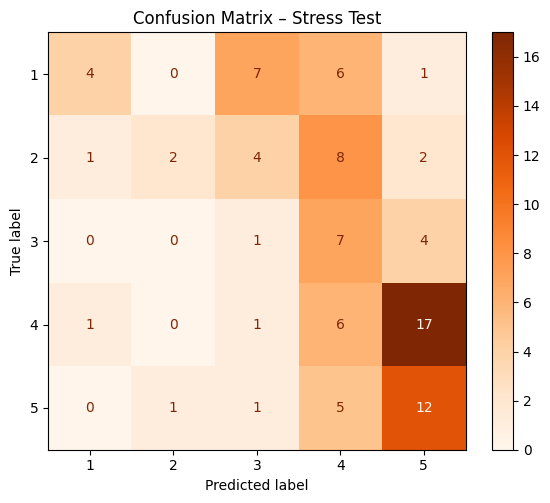

In [25]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_stress_valid, y_stress_pred, ax=ax, cmap="Oranges"
)
ax.set_title("Confusion Matrix – Stress Test")
plt.tight_layout()
plt.show()


## Step 11 – Per-Class Comparison: Decision Tree vs Random Forest

Fill in the DT numbers from your classification notebook to see
class-by-class improvement.


In [26]:
print("=" * 65)
print("COMPARISON: Decision Tree vs Random Forest Classification")
print("=" * 65)

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy (Internal Test)",
        "Accuracy (Stress Test)",
        "F1 Class 1 (cheapest)",
        "F1 Class 2",
        "F1 Class 3",
        "F1 Class 4",
        "F1 Class 5 (most expensive)",
    ],
    "Decision Tree": [
        "0.5292",
        "0.2747",
        "0.65",
        "0.39",
        "0.49",
        "0.24",
        "0.77",
    ],
    "Random Forest": [
        f"{acc:.4f}",
        f"{acc_stress:.4f}",
        "(from report above)",
        "(from report above)",
        "(from report above)",
        "(from report above)",
        "(from report above)",
    ],
})

print(comparison.to_string(index=False))
print("Update the RF column with F1 scores from Step 7.")
print("--- Done! ---")


COMPARISON: Decision Tree vs Random Forest Classification
                     Metric Decision Tree       Random Forest
   Accuracy (Internal Test)        0.5292              0.5625
     Accuracy (Stress Test)        0.2747              0.2747
      F1 Class 1 (cheapest)          0.65 (from report above)
                 F1 Class 2          0.39 (from report above)
                 F1 Class 3          0.49 (from report above)
                 F1 Class 4          0.24 (from report above)
F1 Class 5 (most expensive)          0.77 (from report above)
Update the RF column with F1 scores from Step 7.
--- Done! ---


run the calssifikation 07.09.2026